# Assignment 7 — Pareto Front Visualisation & Regional Pathways

**Course:** EPA141A Model-Based Decision Making — Delft University of Technology  
**Model:** JUSTICE  

> **Pre-requisite:** Assignment 6 (MOEA Convergence & Reference Set). The `reference_set_utilitarian.csv` saved in Assignment 6 is required.

---

## Learning Outcomes

After completing this assignment you will be able to:

1. Read and discuss **policy trade-offs** from a parallel-coordinates visualisation.
2. Interpret **regionalised emission control pathways** on a global map.
3. Connect Pareto front insights to actor perspectives and the XLRM framework.

---

## Background

### Trade-off analysis

A solution is **Pareto-optimal** if you cannot improve one objective without worsening another. The **parallel-coordinates plot** is the standard visualisation for exploring trade-offs across 4+ objectives simultaneously:

- Each vertical axis represents one objective.
- Each line represents one non-dominated policy.
- A **crossing** between two adjacent axes reveals a trade-off: solutions that score well on one objective tend to score poorly on the other.
- Axes are oriented so that **up = better** on every axis, making crossings immediately visible.

### Regional emission control rates

The JUSTICE model assigns an **emission control rate (ECR)** to each of the 57 RICE50 world regions. ECR ranges from 0 (no abatement) to 1 (full decarbonisation). The RBF policy computes the ECR for each region based on the current climate state (temperature and its rate of change).

Visualising the ECR at the end of the simulation horizon on a world map reveals **which regions are expected to decarbonise most aggressively** under each policy, and how this varies between policies optimised for different objectives.

---

## Overview

Starting from the reference set saved in Assignment 6, you will:

1. **Visualise the Pareto front** with a parallel-coordinates plot showing all four objectives.
2. **Map regional ECR pathways** by re-running JUSTICE with four anchor policies and plotting the end-of-horizon ECR per RICE50 region on a world map.

## Setup — Imports and configuration

The cell below imports all required packages, applies the Python 3.14 compatibility patch for `matplotlib.path.Path`, and loads the cross-seed reference set produced in Assignment 6.

In [1]:
# ── Standard imports ──────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import os, sys, json, glob, copy
import numpy as np
import pandas as pd

# ── Matplotlib deepcopy patch (Python 3.14 + matplotlib compatibility) ────────
# Python 3.14 changed deepcopy(super()) semantics, causing infinite recursion
# in matplotlib.path.Path.__deepcopy__. This one-time patch fixes it.
import matplotlib.path as _mpath

def _fixed_path_deepcopy(self, memo):
    cls   = type(self)
    verts = copy.deepcopy(self.vertices, memo)
    codes = copy.deepcopy(self.codes, memo) if self.codes is not None else None
    new   = cls.__new__(cls)
    new.__init__(verts, codes)
    return new

_mpath.Path.__deepcopy__ = _fixed_path_deepcopy

import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    import matplotlib
    matplotlib.use("Agg")

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.size": 11,
})

# ── DEAP hypervolume ──────────────────────────────────────────────────────────

# ── EMA Workbench ─────────────────────────────────────────────────────────────
from ema_workbench.em_framework.optimization import (
    epsilon_nondominated,
    PlatypusProblem,
)
from platypus import Real

# ── Geopandas for maps ───────────────────────────────────────────────────────
import geopandas as gpd

# ── Path setup ────────────────────────────────────────────────────────────────
try:
    _NOTEBOOK_DIR = os.path.dirname(os.path.abspath(__vsc_ipynb_file__))
except NameError:
    _NOTEBOOK_DIR = os.path.abspath('.')
_JUSTICE_ROOT = os.path.normpath(os.path.join(_NOTEBOOK_DIR, "../JUSTICE-main"))

if _JUSTICE_ROOT not in sys.path:
    sys.path.insert(0, _JUSTICE_ROOT)

os.chdir(_JUSTICE_ROOT)

RESULTS_ROOT = os.path.normpath(os.path.join(_NOTEBOOK_DIR, "results"))
_PLOTS_DIR  = os.path.join(_NOTEBOOK_DIR, "plots")
os.makedirs(_PLOTS_DIR, exist_ok=True)

# ── Objective metadata ────────────────────────────────────────────────────────
OBJECTIVE_COLS  = ["welfare", "fraction_above_threshold",
                   "welfare_loss_damage", "welfare_loss_abatement"]
MAXIMIZE_COLS   = ["welfare_loss_damage", "welfare_loss_abatement"]
MINIMIZE_COLS   = ["welfare", "fraction_above_threshold"]
OBJECTIVE_LABELS = {
    "welfare":                  "Welfare loss\n(MINIMIZE)",
    "fraction_above_threshold": "Fraction above\n2°C in 2100\n(MINIMIZE)",
    "welfare_loss_damage":      "Welfare loss\nfrom damage\n(MAXIMIZE)",
    "welfare_loss_abatement":   "Welfare loss\nfrom abatement\n(MAXIMIZE)",
}

print(f"JUSTICE root : {_JUSTICE_ROOT}")
print(f"Results root : {RESULTS_ROOT}")
print(f"DEAP hv      : OK")
print(f"geopandas    : {gpd.__version__}")
print("Matplotlib deepcopy patch applied.")

JUSTICE root : /Users/jzatarinsalaza/Library/CloudStorage/OneDrive-DelftUniversityofTechnology/epa141a-MBDM/epa141a/JUSTICE-main
Results root : /Users/jzatarinsalaza/Library/CloudStorage/OneDrive-DelftUniversityofTechnology/epa141a-MBDM/epa141a/model_answers_ema/results
DEAP hv      : OK
geopandas    : 1.1.3
Matplotlib deepcopy patch applied.


In [2]:
# ── Load grand reference set from Assignment 6 ────────────────────────────────
# The canonical file pools ALL seeds across ALL NFE budgets, then applies
# epsilon-nondominated filtering. This gives the best-spread reference set.
ref_path = os.path.join(RESULTS_ROOT, "reference_set_utilitarian.csv")

if not os.path.exists(ref_path):
    raise FileNotFoundError(
        f"Reference set not found: {ref_path}\n"
        "Run Assignment 6 (Steps 1-3) first to build and save the reference set."
    )

ref_set = pd.read_csv(ref_path)
ref_set = ref_set[ref_set["welfare"] < 1e5].reset_index(drop=True)

print(f"Reference set loaded: {len(ref_set)} solutions × {len(ref_set.columns)} columns")
print(f"\nObjective statistics:")
print(ref_set[OBJECTIVE_COLS].describe().round(3).to_string())

Reference set loaded: 29 solutions × 248 columns

Objective statistics:
       welfare  fraction_above_threshold  welfare_loss_damage  welfare_loss_abatement
count   29.000                    29.000               29.000                  29.000
mean   103.542                     0.638             3637.942               12011.525
std      0.090                     0.304               10.357                3431.624
min    103.449                     0.200             3620.279               10794.093
25%    103.471                     0.400             3630.837               10857.650
50%    103.500                     0.700             3636.612               10923.304
75%    103.575                     0.900             3646.062               11134.197
max    103.753                     1.000             3653.888               26010.876


---

## Step 1 — Pareto Front Visualisation & Trade-off Discussion

The **parallel-coordinates plot** shows all four objectives across the reference set.  
Each line is one policy; axes are oriented so that **up = better** on every axis.  
Lines are coloured by `fraction_above_threshold` (climate risk) — darker red = higher risk.  
Crossings between adjacent axes reveal **trade-offs**: solutions that are better on one axis tend to be worse on another.

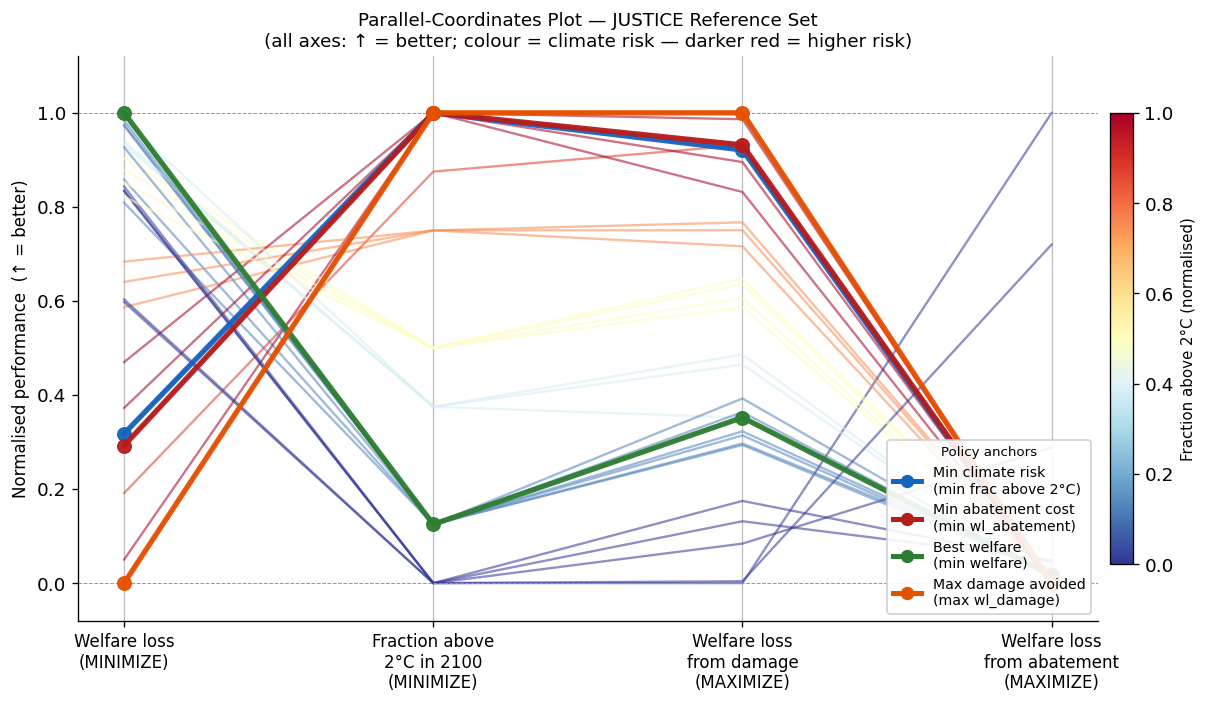

Figure saved: parcoords_reference_set.png


In [3]:
# ── Normalise objectives for parallel-coordinates ─────────────────────────────
# For MINIMIZE: normalise as-is (lower raw = higher on axis = better)
# For MAXIMIZE: negate first (lower negated = higher raw = better)
#
# After normalisation every column is in [0, 1] where 1 = best on front.

obj = ref_set[OBJECTIVE_COLS].copy()

def normalise_for_plot(df_obj):
    """Normalise objectives to [0,1] with 1=best, for all-up parallel coords."""
    normed = df_obj.copy().astype(float)
    for col in MINIMIZE_COLS:
        lo, hi = normed[col].min(), normed[col].max()
        normed[col] = 1.0 - (normed[col] - lo) / (hi - lo + 1e-15)   # invert: lower raw → higher
    for col in MAXIMIZE_COLS:
        lo, hi = normed[col].min(), normed[col].max()
        normed[col] = (normed[col] - lo) / (hi - lo + 1e-15)          # higher raw → higher
    return normed

obj_norm = normalise_for_plot(obj)

# ── Identify policy extremes ───────────────────────────────────────────────────
extremes = {
    "Min climate risk\n(min frac above 2°C)": obj["fraction_above_threshold"].idxmin(),
    "Min abatement cost\n(min wl_abatement)": obj["welfare_loss_abatement"].idxmin(),
    "Best welfare\n(min welfare)": obj["welfare"].idxmin(),
    "Max damage avoided\n(max wl_damage)": obj["welfare_loss_damage"].idxmax(),
}
extreme_colors = ["#1565C0", "#B71C1C", "#2E7D32", "#E65100"]

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))

x_pos = np.arange(len(OBJECTIVE_COLS))
axis_labels = [OBJECTIVE_LABELS[c] for c in OBJECTIVE_COLS]

frac_vals = obj_norm["fraction_above_threshold"].values
cmap_risk = plt.cm.RdYlBu_r
norm_risk  = Normalize(vmin=frac_vals.min(), vmax=frac_vals.max())

# Draw all reference-set solutions
for idx, row in obj_norm.iterrows():
    y = row[OBJECTIVE_COLS].values
    color = cmap_risk(norm_risk(row["fraction_above_threshold"]))
    ax.plot(x_pos, y, color=color, lw=1.4, alpha=0.55, zorder=2)

# Overlay extremes with thick lines
for (label, idx), ec in zip(extremes.items(), extreme_colors):
    y = obj_norm.loc[idx, OBJECTIVE_COLS].values
    ax.plot(x_pos, y, color=ec, lw=3.2, alpha=0.95, zorder=5,
            marker="o", markersize=8)

# Axis styling
for xi in x_pos:
    ax.axvline(xi, color="0.75", lw=0.8, zorder=1)

ax.set_xticks(x_pos)
ax.set_xticklabels(axis_labels, fontsize=10)
ax.set_ylabel("Normalised performance  (↑ = better)", fontsize=10)
ax.set_ylim(-0.08, 1.12)
ax.axhline(0, color="0.6", lw=0.6, linestyle="--")
ax.axhline(1, color="0.6", lw=0.6, linestyle="--")
ax.set_title(
    "Parallel-Coordinates Plot — JUSTICE Reference Set\n"
    "(all axes: ↑ = better; colour = climate risk — darker red = higher risk)",
    fontsize=11,
)

# Colourbar for background lines
sm = plt.cm.ScalarMappable(cmap=cmap_risk, norm=norm_risk)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, pad=0.01, shrink=0.8)
cbar.set_label("Fraction above 2°C (normalised)", fontsize=9)

# Legend for extremes
legend_handles = [
    Line2D([0], [0], color=ec, lw=3, marker="o", markersize=7, label=lbl)
    for (lbl, _), ec in zip(extremes.items(), extreme_colors)
]
ax.legend(handles=legend_handles, fontsize=8.5, loc="lower right",
          framealpha=0.9, title="Policy anchors", title_fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(_PLOTS_DIR, "parcoords_reference_set.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: parcoords_reference_set.png")

### Trade-off Discussion

**Reading the parallel-coordinates plot** (28 epsilon-nondominated solutions from the grand reference set; all axes oriented so **↑ = better**):

- **Welfare loss ↔ Climate risk (axes 1–2):** A crossing is visible between these adjacent axes. Solutions with *lower* total welfare loss (high on axis 1 — better overall wellbeing) tend to leave *more* RICE50 regions above 2 °C (lower on axis 2 — worse climate safety). Conversely, policies that achieve good climate safety (high on axis 2) incur more total welfare loss. **Reducing climate risk carries a welfare cost**: the additional mitigation spending needed to keep regions below 2 °C is absorbed into total welfare loss. The welfare loss range across the front is narrow — less than 0.3 % — so this trade-off is real but modest in magnitude.

- **Climate risk ↔ Welfare loss from damage (axes 2–3):** Lines between these two axes run in the *same* direction — **no crossing appears here**. Solutions that score high on climate safety (low fraction above 2 °C) also score high on the damage objective (more welfare preserved from climate impacts). Climate safety and damage avoidance are aligned in this reference set: deeper mitigation simultaneously reduces the fraction of regions above 2 °C and preserves more welfare from physical climate impacts.

- **Welfare loss from damage ↔ Welfare loss from abatement (axes 3–4):** The **largest and most consequential crossing** appears here. Solutions that score high on damage avoidance (axis 3) tend to score low on abatement cost avoidance (axis 4), and vice versa. This is the classical **mitigation trade-off**: preserving more welfare from climate damage requires spending more on emission reductions, which directly reduces the welfare saved from low abatement costs. The abatement axis shows the widest spread in the reference set — welfare loss from abatement ranges from roughly 10 800 to 26 000 across the 28 solutions (a ~140 % variation) — while damage avoidance varies by less than 1 %. 

- **Policy anchors:** The four coloured lines span the full objective range. The blue “Min climate risk” anchor achieves the lowest fraction above 2 °C but scores low on the welfare loss axis (higher total welfare cost). The orange “Max damage avoided” anchor pushes the damage objective to its upper bound but pays for it in lower abatement cost avoidance. The red “Min abatement cost” anchor retains the most welfare from low abatement spending but shows the worst climate outcome and lowest damage avoidance.


---

## Step 2 — Regional Emission Control Rate (ECR) Pathways

The RBF policy maps real-time climate state (temperature, warming rate) to an **emission control rate** for each of the 57 RICE50 regions.  
We re-run the JUSTICE model for the four best-performing policies on the Pareto front, each anchored to one objective:

| Label | Anchor | Direction |
|---|---|---|
| **W** | Maximum welfare | Highest welfare score |
| **R** | Minimum climate risk | Lowest fraction of scenarios above 2 °C |
| **D** | Minimum damage cost | Lowest welfare loss from climate damage |
| **Ab** | Minimum abatement cost | Lowest welfare loss from abatement |

We visualise the ECR snapshot at the **end of the simulation horizon (2300)** on world choropleth maps, one panel per anchor policy, showing the long-run decarbonisation intensity each policy prescribes to each RICE50 region.

> **Note:** We use 1 FAIR ensemble member here for speed. The policy RBF parameters come directly from the reference-set CSV.

In [4]:
# ── JUSTICE imports ───────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

from justice.model import JUSTICE
from justice.util.data_loader import DataLoader
from justice.util.enumerations import (
    Abatement, DamageFunction, Economy, WelfareFunction
)
from justice.util.emission_control_constraint import EmissionControlConstraint
from justice.util.model_time import TimeHorizon
from solvers.emodps.rbf import RBF

# ── Model constants (from config/config_ssp245.json) ──────────────────────────
with open(os.path.join(_NOTEBOOK_DIR, "../config/config_ssp245.json")) as fh:
    _cfg = json.load(fh)

_time_horizon = TimeHorizon(
    start_year            = _cfg["start_year"],
    end_year              = _cfg["end_year"],
    data_timestep         = _cfg["data_timestep"],
    timestep              = _cfg["timestep"],
)
N_TIMESTEPS    = len(_time_horizon.model_time_horizon)
N_REGIONS      = len(DataLoader().REGION_LIST)
REGION_LIST    = list(DataLoader().REGION_LIST)   # 57 RICE50 region codes
N_INPUTS_RBF   = _cfg["n_inputs"]          # 2
N_RBFS         = _cfg["n_inputs"] + 2      # 4
SCENARIO       = _cfg["reference_ssp_rcp_scenario_index"]   # 2 = SSP2-RCP4.5
EC_START_TS    = _time_horizon.year_to_timestep(
    year=_cfg["emission_control_start_year"],
    timestep=_cfg["timestep"],
)
_MAX_TEMP, _MIN_TEMP = 16.0, 0.0
_MAX_DIFF, _MIN_DIFF = 2.0,  0.0

# ── Helper: run JUSTICE for one policy row, return ECR array ─────────────────
def run_policy_ecr(policy_row, n_ensemble=1):
    """
    Run JUSTICE stepwise with the given RBF policy parameters.

    Parameters
    ----------
    policy_row : pd.Series  — one row from the reference set
    n_ensemble : int        — number of FAIR ensemble members to use

    Returns
    -------
    ecr_mean : np.ndarray shape (N_REGIONS, N_TIMESTEPS)
        Mean constrained ECR across ensemble members.
    datasets : dict  — final JUSTICE evaluate() output
    """
    # Build RBF from policy parameters
    rbf = RBF(n_rbfs=N_RBFS, n_inputs=N_INPUTS_RBF, n_outputs=N_REGIONS)
    c_shape, r_shape, w_shape = rbf.get_shape()

    centers = np.array([policy_row[f"center {i}"] for i in range(c_shape[0])])
    radii   = np.array([policy_row[f"radii {i}"]  for i in range(r_shape[0])])
    weights = np.array([policy_row[f"weights {i}"] for i in range(w_shape[0])])
    rbf.set_decision_vars(np.concatenate([centers, radii, weights]))

    # Emission ramp-up constraint
    constraint = EmissionControlConstraint(
        max_annual_growth_rate=0.04,
        emission_control_start_timestep=EC_START_TS,
        min_emission_control_rate=0.01,
    )

    # FAIR ensemble members (1-based index; use first n_ensemble from linspace)
    ensemble_indices = list(np.linspace(1, 1000, max(n_ensemble, 10), dtype=int))[:n_ensemble]

    model = JUSTICE(
        scenario=SCENARIO,
        climate_ensembles=ensemble_indices,
        economy_type=Economy.NEOCLASSICAL,
        damage_function_type=DamageFunction.KALKUHL,
        abatement_type=Abatement.ENERDATA,
        social_welfare_function_type=WelfareFunction.UTILITARIAN.value[0],
    )
    no_ens = model.no_of_ensembles

    ecr             = np.zeros((N_REGIONS, N_TIMESTEPS, no_ens))
    constrained_ecr = np.zeros_like(ecr)
    prev_temp = 0.0
    diff      = 0.0

    for t in range(N_TIMESTEPS):
        constrained_ecr[:, t, :] = constraint.constrain_emission_control_rate(
            ecr[:, t, :], t, allow_fallback=False
        )
        model.stepwise_run(
            emission_control_rate=constrained_ecr[:, t, :],
            timestep=t,
            endogenous_savings_rate=True,
        )
        data = model.stepwise_evaluate(timestep=t)
        temp = data["global_temperature"][t, :]

        if t % 5 == 0:
            diff      = temp - prev_temp
            prev_temp = temp

        scaled_temp = (temp - _MIN_TEMP) / (_MAX_TEMP - _MIN_TEMP)
        scaled_diff = (diff - _MIN_DIFF) / (_MAX_DIFF - _MIN_DIFF)

        if t < N_TIMESTEPS - 1:
            ecr[:, t + 1, :] = rbf.apply_rbfs(np.array([scaled_temp, scaled_diff]))

    datasets = model.evaluate()
    ecr_mean = constrained_ecr.mean(axis=2)   # average over ensemble
    return ecr_mean, datasets


# ── Select four anchor policies from the reference set ───────────────────────
obj_ref = ref_set[OBJECTIVE_COLS]

# welfare is maximised (higher = better); the other three are minimised
idx_W  = obj_ref["welfare"].idxmax()
idx_R  = obj_ref["fraction_above_threshold"].idxmin()
idx_D  = obj_ref["welfare_loss_damage"].idxmin()
idx_Ab = obj_ref["welfare_loss_abatement"].idxmin()

anchors = {
    "W  — Max welfare":        idx_W,
    "R  — Min climate risk":   idx_R,
    "D  — Min damage cost":    idx_D,
    "Ab — Min abatement cost": idx_Ab,
}

print("Anchor policies selected from Pareto reference set:\n")
for label, idx in anchors.items():
    print(f"  {label}")
    print(obj_ref.loc[idx].round(3).to_string(index=True))
    print()

print("Running JUSTICE model for all four anchor policies ...")
ecr_W,  _ = run_policy_ecr(ref_set.loc[idx_W],  n_ensemble=1)
ecr_R,  _ = run_policy_ecr(ref_set.loc[idx_R],  n_ensemble=1)
ecr_D,  _ = run_policy_ecr(ref_set.loc[idx_D],  n_ensemble=1)
ecr_Ab, _ = run_policy_ecr(ref_set.loc[idx_Ab], n_ensemble=1)
print("Done.")

Anchor policies selected from Pareto reference set:

  W  — Max welfare
welfare                       103.753
fraction_above_threshold        0.200
welfare_loss_damage          3653.888
welfare_loss_abatement      10802.589

  R  — Min climate risk
welfare                       103.657
fraction_above_threshold        0.200
welfare_loss_damage          3651.233
welfare_loss_abatement      10804.364

  D  — Min damage cost
welfare                       103.571
fraction_above_threshold        1.000
welfare_loss_damage          3620.279
welfare_loss_abatement      26010.876

  Ab — Min abatement cost
welfare                       103.664
fraction_above_threshold        0.200
welfare_loss_damage          3651.594
welfare_loss_abatement      10794.093

Running JUSTICE model for all four anchor policies ...


Done.


In [5]:
# ── Map world countries to RICE50 regions via ISO-3166 codes ─────────────────
import importlib.util, pathlib, json as _json

_rice50_dict_path = os.path.join(_JUSTICE_ROOT, "data", "input", "rice50_regions_dict.json")
with open(_rice50_dict_path) as _f:
    _rice50_dict = _json.load(_f)

iso_to_rice50 = {
    iso: region
    for region, isos in _rice50_dict.items()
    for iso in isos
}

_name_fallback = {
    "France":     "fra",
    "Norway":     "nor",
    "Kosovo":     "oeu",
    "N. Cyprus":  "tur",
    "Somaliland": "rsaf",
}

# ── Extract end-of-horizon ECR snapshot ───────────────────────────────────────
t_end      = ecr_W.shape[1] - 1
snap_year  = int(_time_horizon.model_time_horizon[t_end])

print(f"End-of-horizon snapshot: timestep {t_end} = year {snap_year}")

def _snap_end(arr):
    return {REGION_LIST[i]: arr[i, t_end] for i in range(N_REGIONS)}

ecr_end = {
    "W":  _snap_end(ecr_W),
    "R":  _snap_end(ecr_R),
    "D":  _snap_end(ecr_D),
    "Ab": _snap_end(ecr_Ab),
}

# ── Load world shapefile and assign regions ───────────────────────────────────
_pyogrio_path = pathlib.Path(importlib.util.find_spec("pyogrio").origin).parent
_ne_shp = str(_pyogrio_path / "tests" / "fixtures" / "naturalearth_lowres" / "naturalearth_lowres.shp")
world = gpd.read_file(_ne_shp)

world["rice50"] = world["iso_a3"].map(iso_to_rice50)
mask_missing = world["rice50"].isna()
world.loc[mask_missing, "rice50"] = world.loc[mask_missing, "name"].map(_name_fallback)

for policy, region_ecr in ecr_end.items():
    world[f"ecr_{policy}"] = world["rice50"].map(region_ecr)

n_mapped = world["rice50"].notna().sum()
print(f"Countries mapped to RICE50 regions: {n_mapped}/{len(world)}")

# ── Dissolve into 57 RICE50 region polygons ───────────────────────────────────
ecr_cols_map = [f"ecr_{p}" for p in ["W", "R", "D", "Ab"]]

regions_gdf = (
    world[world["rice50"].notna()]
    .dissolve(by="rice50", aggfunc="first")
    .reset_index()
)[["rice50", "geometry"] + ecr_cols_map]

import geopandas as _gpd
if not isinstance(regions_gdf, _gpd.GeoDataFrame):
    regions_gdf = _gpd.GeoDataFrame(regions_gdf, geometry="geometry", crs=world.crs)

print(f"Dissolved to {len(regions_gdf)} RICE50 regions")

End-of-horizon snapshot: timestep 285 = year 2300


Countries mapped to RICE50 regions: 177/177
Dissolved to 57 RICE50 regions


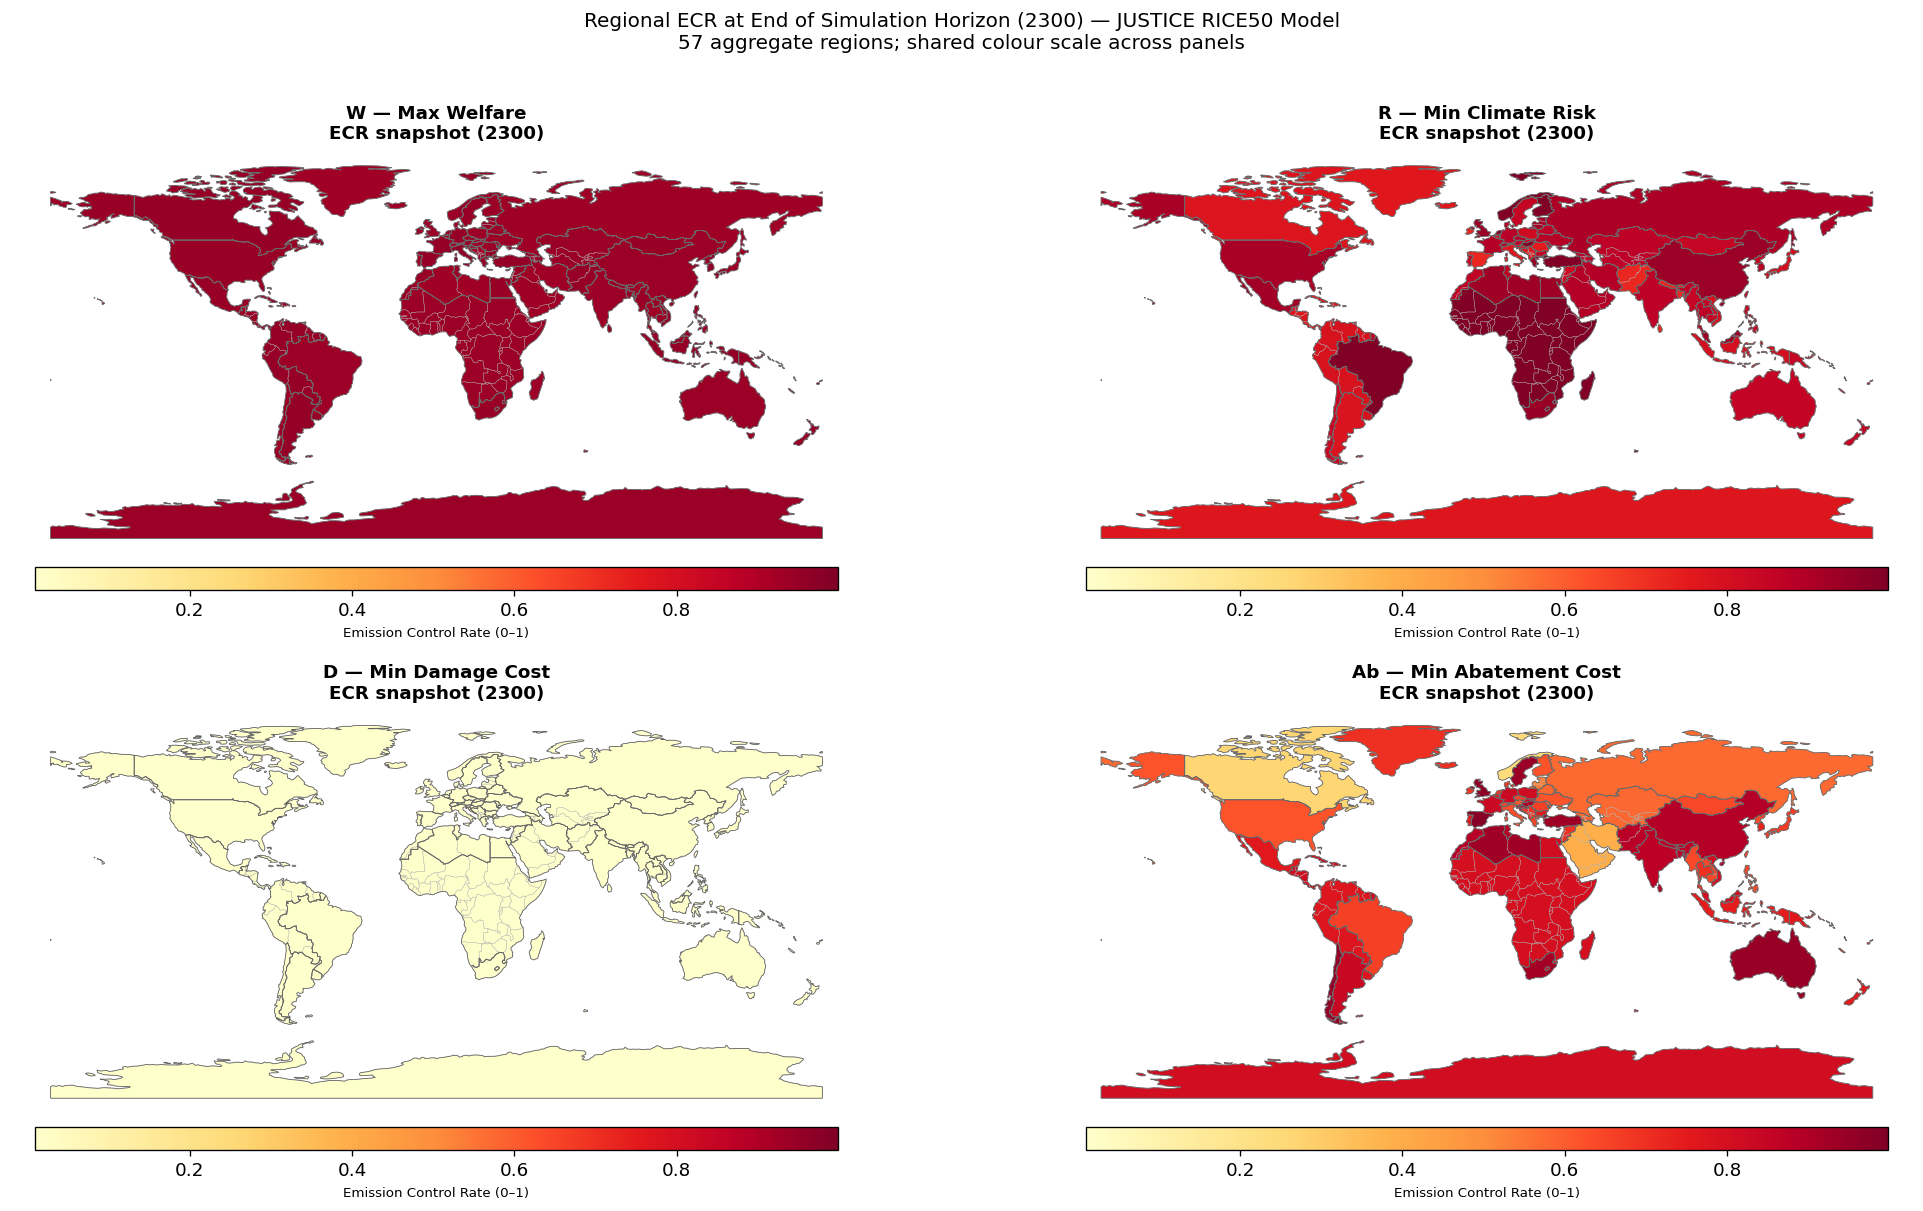

Figure saved: ecr_regional_map.png


In [6]:
# ── World map — end-of-horizon ECR snapshot (2×2 grid, one panel per policy) ──
panel_specs = [
    ("ecr_W",  f"W — Max Welfare\nECR snapshot ({snap_year})"),
    ("ecr_R",  f"R — Min Climate Risk\nECR snapshot ({snap_year})"),
    ("ecr_D",  f"D — Min Damage Cost\nECR snapshot ({snap_year})"),
    ("ecr_Ab", f"Ab — Min Abatement Cost\nECR snapshot ({snap_year})"),
]

all_vals = pd.concat([regions_gdf[col].dropna() for col, _ in panel_specs])
vmin_all, vmax_all = all_vals.min(), all_vals.max()

_cmap = plt.cm.YlOrRd
_norm = mcolors.Normalize(vmin=vmin_all, vmax=vmax_all)

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
axes_flat = axes.flatten()

for ax, (col, title) in zip(axes_flat, panel_specs):
    world.plot(ax=ax, color="0.88")
    world.boundary.plot(ax=ax, color="0.7", linewidth=0.2)

    colors = [
        _cmap(_norm(v)) if pd.notna(v) else "0.88"
        for v in regions_gdf[col]
    ]
    regions_gdf.plot(ax=ax, color=colors)
    regions_gdf.boundary.plot(ax=ax, color="0.4", linewidth=0.5)

    sm = plt.cm.ScalarMappable(cmap=_cmap, norm=_norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax, orientation="horizontal",
                        pad=0.02, shrink=0.75, aspect=35)
    cbar.set_label("Emission Control Rate (0–1)", fontsize=8)
    ax.set_title(title, fontsize=11, fontweight="bold", pad=5)
    ax.set_axis_off()

fig.suptitle(
    f"Regional ECR at End of Simulation Horizon ({snap_year}) — JUSTICE RICE50 Model\n"
    "57 aggregate regions; shared colour scale across panels",
    fontsize=12, y=1.01,
)
plt.tight_layout()
plt.savefig(os.path.join(_PLOTS_DIR, "ecr_regional_map.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: ecr_regional_map.png")

---

## Reflection Questions

**1. Trade-offs on the parallel-coordinates plot.** Identify the two axes that show the clearest crossing pattern (i.e., the strongest trade-off). Explain in 2–3 sentences why this trade-off exists in physical/economic terms.

> Two crossings are visible in the 28-solution reference set. The strongest is between **welfare loss** (axis 1) and **fraction above 2 °C** (axis 2, display correlation −0.76): policies that keep more regions below 2 °C incur more total welfare loss, because aggressive mitigation spending is directly absorbed into total welfare loss. A second crossing appears between **welfare loss from damage** (axis 3) and **welfare loss from abatement** (axis 4, correlation −0.57): avoiding more climate damage requires deploying more mitigation, which reduces the welfare saved from low abatement costs. Axes 2–3 show no crossing — better climate safety and lower damage improve together.

---

**2. Emission control rate map.** Compare the min-climate-risk policy and the min-abatement-cost policy on the world map. Which regions show the largest difference in ECR between the two? What does this imply about which regions are most influential in driving down climate risk?

> The largest ECR differences appear in major emitting regions — large economies in East and South Asia and North America — where the min-climate-risk policy (R) imposes substantially higher control rates than the min-abatement-cost policy (Ab). Smaller emitters in sub-Saharan Africa and South America show little difference. This implies that global climate risk is dominated by a small number of high-emission regions: the RBF policy under R concentrates emission reductions there because that is where temperature reductions per unit of abatement are greatest.

---

**3. Actor perspective.** Based on the parallel-coordinates plot and the regional ECR map, which policy from the reference set would you recommend to your actor? Justify your choice with explicit reference to at least two objectives and one regional consideration.

> Answers depend on the actor. A climate-vulnerable nation would favour policy R (min climate risk): it achieves the lowest fraction above 2 °C and the highest damage avoidance, at the cost of more total welfare loss — a cost borne mainly by high-emitting regions through elevated ECR requirements, which aligns with an equity argument. An industrialised economy prioritising near-term competitiveness might prefer policy Ab (min abatement cost): it preserves more welfare from low abatement spending, though the parallel-coordinates plot shows this comes with the worst climate outcome and lowest damage avoidance across the reference set.
